# 01 · Getting to know the data

*Rent Reality Check — London. Created by **Kevin Steepan** as a student portfolio
project: real data, a real question, and every step explained.*

---

## What this notebook is (in one minute)

I have a spreadsheet of ~93,000 London Airbnb listings. The end goal of the project
is a tool that, given a listing, says **"a fair price for this is about £X a night"**
and explains why.

Before building anything, you have to *look at the data*. This first notebook does
that looking. It's called **EDA — exploratory data analysis** — and its whole job
is to answer three practical questions so the rest of the project rests on solid
ground:

1. **What number are we actually trying to predict?** (The nightly price? Something
   derived from it?)
2. **Which listings should count?** (All of them, or a sensible slice?)
3. **What's the "dumb" score to beat?** If a complicated model can't beat *"just
   guess the average price for that area"*, the model is pointless.

Two smaller checks come along for the ride: is there enough written text in the
listings to be worth analysing later, and does location visibly matter.

> 📚 **Why start this way?** "Frame the problem, get the data, explore, build a
> quick baseline, *then* model" is the standard project arc in Aurélien Géron's
> *Hands-On Machine Learning* (Ch. 2) and in Google's *Rules of Machine Learning*
> (Rule #1: know your simple baseline before you reach for ML).

## The decisions this notebook reaches (put at the top so you don't have to hunt)

These are filled in **after** the exploration below — they're up here so a reader
knows the conclusions before wading through the charts. Each links to the section
that justifies it.

| # | Decision | One-line reason |
|---|---|---|
| 1 | Predict **`log(price)`**, not raw £ | prices are lopsided; logging makes errors behave like *percentages* and stops giant listings dominating |
| 2 | Keep listings **£10–£1000 / night** | below £10 is almost always a typo; above £1000 is a tiny luxury world that prices differently |
| 3 | Keep **entire homes + private rooms** only | hotel and shared rooms are a different product sold on different logic |
| 4 | Drop the **33% with no price** — but flag that it's *not random* | missing-price rates vary by area and room type, so the model describes *priced* listings |
| 5 | **Baseline to beat:** guess the borough × room-type median → **£-MAE ≈ 90, R² ≈ 0.49** | anything we build has to clearly beat a lookup table |

Full reasoning for each is in the matching section below.

In [1]:
# --- setup -------------------------------------------------------------------
# londonrent is the project's own small library (src/londonrent/). Keeping the
# data-loading logic in a module instead of pasting it into every notebook is a
# habit worth showing: notebooks stay readable, and the exact same cleaning code
# runs in the Streamlit app later.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from londonrent.data import build_interim

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

# build_interim():
#   1. reads the raw Inside Airbnb CSV (data/raw/listings.csv.gz),
#   2. does the unavoidable cleaning - turn "$1,234.00" strings into the number
#      1234.0, parse the date columns, parse the "1.5 shared baths" text, and
#      throw away rows whose lat/long fall outside a box around London,
#   3. caches the result as a Parquet file so re-running is instant.
# It does NOT filter by price or room type yet - that's a modelling decision we
# make deliberately further down, not something to bury in a loader.
df = build_interim()
print(f"{len(df):,} listings  x  {df.shape[1]} columns")
df[["price", "room_type", "bedrooms", "neighbourhood_cleansed", "number_of_reviews"]].head()

92,638 listings  x  36 columns


,price,room_type,bedrooms,neighbourhood_cleansed,number_of_reviews
0,234.5,Entire home/apt,1.0,Lambeth,196
1,127.0,Private room,NaN,Islington,57
2,137.5,Entire home/apt,1.0,Kensington and Chelsea,98
3,606.67,Entire home/apt,3.0,Westminster,57
4,68.3,Private room,1.0,Lambeth,43


## 1 · What are we predicting? A look at price

Everything hinges on the target variable. We check two things: **how often `price`
is even filled in**, and **what shape its distribution has** — because that shape
decides whether we model the raw pound figure or a transformed version of it.

In [2]:
# How much price data do we actually have?
missing = df["price"].isna().mean()
print(f"price is missing for {missing:.1%} of listings\n")

# describe() on the non-missing prices. The percentiles matter more than the mean
# here: if the 99th percentile is miles above the 75th, we've got a heavy tail.
price = df["price"].dropna()
price.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2)

price is missing for 32.8% of listings



count     62240.0
mean       271.47
std        2190.6
min          2.23
1%           35.0
5%          50.75
25%         100.0
50%         180.0
75%        300.03
95%         676.0
99%       1373.46
max      527524.0
Name: price, dtype: Float64

**What the numbers say, plainly.** A third of listings have no price at all (we
deal with that in section 2). Among the rest, half are below ~£180/night, but the
top 1% run past £1000 and the maximum is absurd (£500k — clearly junk). The
**average (£271) sits well above the middle value (£180)** because those few huge
numbers drag it up. That's the classic signature of a *right-skewed* distribution.

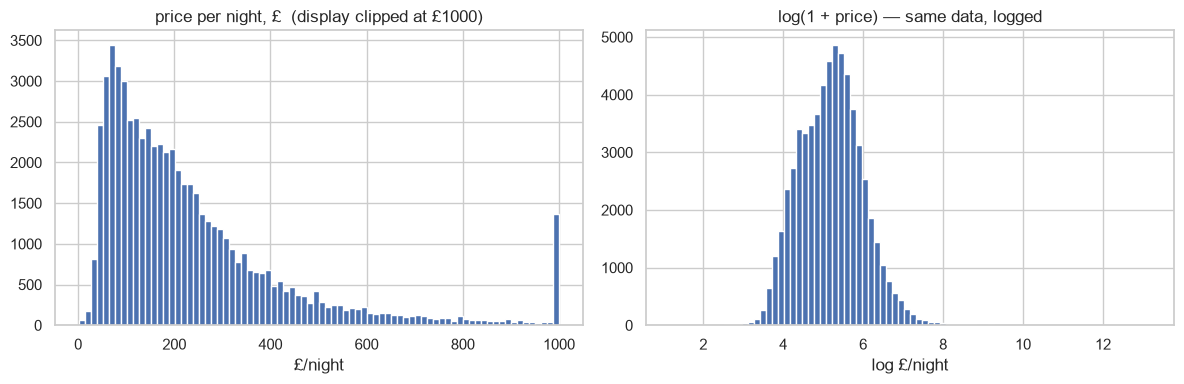

In [3]:
# Two views of the same data. Left: raw £, clipped at £1000 just so the bars for
# the bulk of listings are visible (without the clip, a handful of £500k listings
# squash everything into the first pixel). Right: the natural log of price.
#
# I plotted the raw version first, saw it was unreadable, added the clip for
# display, and that made the skew obvious - which is what pushed me toward a log
# transform for the actual modelling.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
price.clip(upper=1000).hist(bins=80, ax=ax[0])
ax[0].set_title("price per night, £  (display clipped at £1000)")
ax[0].set_xlabel("£/night")
np.log1p(price).hist(bins=80, ax=ax[1])   # log1p = log(1 + x), safe if any x is 0
ax[1].set_title("log(1 + price) — same data, logged")
ax[1].set_xlabel("log £/night")
plt.tight_layout()

### Deeper: why a skewed target is a problem, and why `log` fixes it

*(This part assumes you've met linear regression / mean-squared error. If not,
skip to section 2 — the plain takeaway is "we predict `log(price)` and convert
back".)*

Most regression models minimise **squared error**. Squaring means a listing that's
£400 off contributes 100× as much to the loss as one that's £40 off. With a heavy
right tail, the model ends up bending itself to reduce error on a few thousand-pound
listings at the expense of the tens of thousands of ordinary ones. R² has the same
problem — it's variance-based, so the tail dominates it.

Taking `log(price)` does three useful things at once:

- **Squashes the tail.** `log(120)=4.79`, `log(1200)=7.09` — a 10× jump in price is
  a fixed `+2.30` step in log space, so extreme listings stop being outliers.
- **Turns additive errors into multiplicative ones.** An error of `0.1` in log
  space is "about 10% off" *regardless of whether the listing is £50 or £500*.
  That's exactly how a host thinks about pricing, and it means one model works
  across the whole range.
- **Makes the spread of errors roughly constant** across the price range
  (statisticians call this *homoscedasticity*), which is an assumption the
  squared-error loss is implicitly making anyway.

The cost is small: predictions come out in log space and we call `np.exp()` to get
pounds back. We always *also* report the plain-£ error so nobody has to think in
logs.

**What I'd experiment with next:** a model trained with a tail-robust loss directly
(Huber, or quantile/"pinball" loss for prediction intervals) instead of logging —
worth comparing in a v2.

> 📚 Transforming a skewed response to stabilise error variance: ISLR (*An
> Introduction to Statistical Learning*) §3.3.3, "Potential Problems", point 3. The
> intuition for the squared-error/outlier interaction is covered well in the
> StatQuest videos on linear models.

## 2 · Is the missing price *random*? (This changes what we're allowed to claim)

A third of listings have no price. We're going to drop those for modelling — you
can't learn a price from a listing that doesn't state one. The question is whether
that's a harmless loss of sample size or a quiet bias.

In [4]:
# If the missing-price listings look just like the rest, dropping them only costs
# us data. If they're systematically different, the model we build is silently
# about a biased sub-population. Cheapest check: does "no price" line up with
# obvious things like room type and borough?
df["price_missing"] = df["price"].isna()
by_room = df.groupby("room_type")["price_missing"].mean().sort_values(ascending=False)
by_boro = df.groupby("neighbourhood_cleansed")["price_missing"].mean().sort_values(ascending=False)
print("share with a MISSING price, by room type:\n", by_room.round(3).to_string(), "\n")
print("highest-missing boroughs:\n", by_boro.head(8).round(3).to_string())

share with a MISSING price, by room type:
 room_type
Hotel room         0.400
Private room       0.358
Entire home/apt    0.314
Shared room        0.099 

highest-missing boroughs:
 neighbourhood_cleansed
Hackney          0.492
Islington        0.431
Lambeth          0.407
Tower Hamlets    0.405
Lewisham         0.395
Haringey         0.387
Southwark        0.387
Wandsworth       0.381


**Plain reading.** The missing-price rate isn't flat — it changes with room type
and with borough. So the listings we're forced to drop are **not a random sample**
of London.

### Deeper: MCAR vs MAR vs MNAR, and why it matters here

Missing data comes in three flavours (Rubin's framework):

- **MCAR** — *missing completely at random*. The gaps are pure chance. Dropping
  them is safe, you just lose sample size.
- **MAR** — *missing at random* given what you observe. The gaps depend on other
  columns you *have* (e.g. certain boroughs). Handleable, with care.
- **MNAR** — *missing not at random*. The gaps depend on the missing value itself
  (e.g. very cheap or very expensive hosts hide the price). The hardest case.

Our check shows it's at least **MAR** (missingness tracks borough and room type),
and could be **MNAR** (we can't rule out that price itself drives the hiding). The
key point: **the missing value here is the target**. You can impute a missing
*feature*; you can't sensibly impute the very thing you're trying to predict. So
the honest response isn't a statistical fix — it's *scope disclosure*: say clearly
that the model describes **"listings that publish a nightly price"**, and don't
over-claim beyond that.

> 📚 The MCAR/MAR/MNAR distinction is from Donald Rubin's missing-data framework; a
> friendly applied treatment is in the scikit-learn `impute` user guide and in
> Géron Ch. 2.

## 3 · Which columns look like they matter?

A quick scan for the obvious price drivers, so section 5's baseline and the later
model aren't flying blind.

60,648 listings in scope



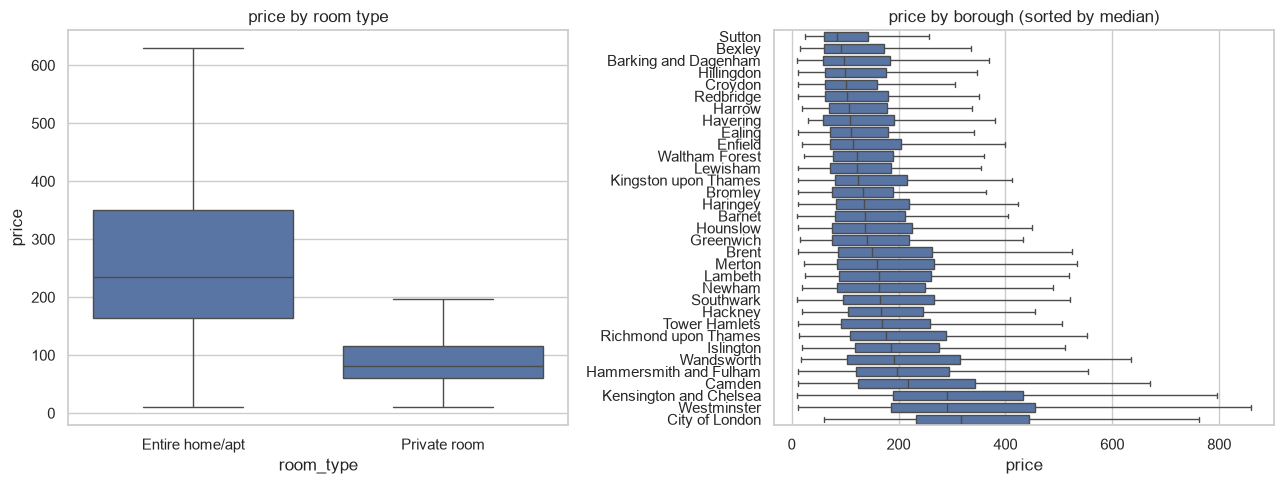

In [5]:
# Apply the Week-1 scope from here on: £10-1000/night, entire-home + private-room.
# (Reasoning for these exact cutoffs is in the decisions table up top and in
# section 5 / the modelling notebook - here we just need a clean slice to look at.)
work = df[df["price"].between(10, 1000) &
         df["room_type"].isin(["Entire home/apt", "Private room"])].copy()
work["log_price"] = np.log(work["price"])
print(f"{len(work):,} listings in scope\n")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(work, x="room_type", y="price", ax=ax[0], showfliers=False)  # hide outliers: they blow up the y-axis
ax[0].set_title("price by room type")
# sort boroughs by median price so the chart tells a story left-to-right
order = work.groupby("neighbourhood_cleansed")["price"].median().sort_values().index
sns.boxplot(work, y="neighbourhood_cleansed", x="price", order=order, ax=ax[1], showfliers=False)
ax[1].set_ylabel(""); ax[1].set_title("price by borough (sorted by median)")
plt.tight_layout()

In [6]:
# Correlation of each numeric feature with log_price. One number in [-1, 1] per
# feature: how strong is the *straight-line* relationship with price.
# I use log_price (not raw price) so the correlations aren't themselves distorted
# by the skew we just discussed.
num = ["accommodates", "bedrooms", "beds", "bathrooms", "amenity_count",
       "minimum_nights", "number_of_reviews", "review_scores_rating",
       "review_scores_location", "host_years", "availability_365"]
corr = work[num + ["log_price"]].corr(numeric_only=True)["log_price"].drop("log_price")
corr.sort_values(ascending=False).to_frame("corr with log_price").round(3)

,corr with log_price
accommodates,0.619
beds,0.490
bedrooms,0.439
amenity_count,0.329
bathrooms,0.316
review_scores_location,0.136
review_scores_rating,0.052
availability_365,0.028
host_years,0.027
number_of_reviews,-0.103


**Plain reading.** Size wins: `accommodates`, `bedrooms`, `beds`, `bathrooms` have
the clearest positive link with price — bigger place, higher price. Borough medians
fan out across a wide band. The *number* of reviews barely moves with price; review
*scores* nudge up a little.

### Deeper: how to read these, and what they don't tell you

- **A correlation of 0.3 is not "30% of the effect".** It means: fit a straight
  line of `log_price` against that feature alone, and it explains `0.3² = 9%` of
  the variation. Individually modest — normal for a multi-causal thing like price.
- **These are *linear* summaries only.** A feature can have a strong *curved* or
  *interaction* relationship with price and still score ≈ 0 here. Example:
  `minimum_nights` might not matter until it crosses ~28 nights (a different market),
  which a single correlation number can't see.
- So this table is a **sniff test** — "do the strong features point the way common
  sense says?" (yes) — **not feature selection**. Dropping a feature because its
  univariate correlation is small is a classic beginner mistake; the tree model
  later gets to decide what's useful in combination.

> 📚 Interpreting correlation and the "don't select features on univariate
> correlation alone" warning: ISLR §3.2, and the scikit-learn feature-selection
> user guide.

Text(0, 0.5, 'latitude')

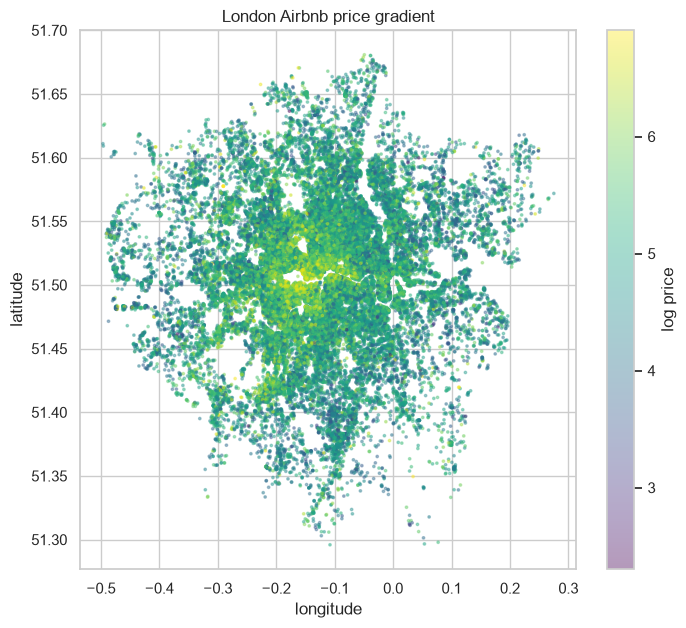

In [7]:
# Location, eyeballed. Plot every listing at its coordinates, colour = log price.
# No model, just a scatter - if there's a visible pattern, location is worth
# engineering features from (which is exactly what notebook 02 does).
fig, ax = plt.subplots(figsize=(8, 7))
s = ax.scatter(work["longitude"], work["latitude"], c=work["log_price"],
               s=3, alpha=.4, cmap="viridis")
fig.colorbar(s, label="log price")
ax.set_title("London Airbnb price gradient")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")

**What we see.** A bright, expensive core over central London that fades outward —
a smooth *price gradient* in space. The borough label captures this only coarsely
(a borough is a big area), so notebook 02 builds finer location features: distance
to the nearest Tube station, to the centre, to a park, and so on.

## 4 · Is there enough text for the language analysis later?

One planned part of the project asks whether *how a host writes the description*
predicts price on top of the hard facts. That only works if descriptions have
enough words in them.

In [8]:
for col in ["description", "neighborhood_overview"]:
    present = df[col].notna().mean()
    wc = df[col].dropna().astype(str).str.split().str.len()
    med = wc.median() if len(wc) else float("nan")
    print(f"{col:22s} present for {present:5.1%}  |  median length: {med} words")

print("\nExample description:\n", df["description"].dropna().iloc[0][:400])

description            present for 97.7%  |  median length: 69.0 words
neighborhood_overview  present for  0.0%  |  median length: nan words

Example description:
 Live like a local in this quintessential London flat, boasting a well-equipped kitchen for home-cooked feasts, vintage chic with real oil paintings adding a touch of artistic flair, and a buzzing ambience that pulsates with the rhythm of this dynamic neighbourhood.<br />Immerse yourself in the vibrant buzz just outside your door, then hop on the Tube (3 mins!) and conquer London (10 mins away!). D


**What we see.** `description` is filled in for ~98% of listings, median ~69 words
— plenty to work with. `neighborhood_overview` is **empty in this data snapshot**
(a quirk of this particular download), so the text analysis will use `description`
alone. Good to know now rather than halfway through notebook 04.

## 5 · The score to beat

Before building a model, decide what "good" means. We do that by measuring how well
you can predict price with **no model at all** — just a lookup table of averages.

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

# Three lookup-table "models", increasing in cleverness:
#   1. always guess the overall median price
#   2. guess the median price of the listing's borough
#   3. guess the median for the (borough, room_type) combination
# transform("median") broadcasts each group's median back onto every row in it.
w = work.dropna(subset=["log_price"]).copy()
guesses = {
    "guess the global median":         w["log_price"].median(),
    "guess the borough median":        w.groupby("neighbourhood_cleansed")["log_price"].transform("median"),
    "guess the borough x room median":  w.groupby(["neighbourhood_cleansed", "room_type"])["log_price"].transform("median"),
}
for name, pred in guesses.items():
    pred = np.broadcast_to(pred, w["log_price"].shape)
    # report error in log space AND in real £ (exp() undoes the log)
    print(f"{name:32s} | log-MAE {mean_absolute_error(w['log_price'], pred):.3f} "
          f"| £-MAE {mean_absolute_error(np.exp(w['log_price']), np.exp(pred)):6.1f} "
          f"| R² {r2_score(w['log_price'], pred):.3f}")

guess the global median          | log-MAE 0.606 | £-MAE  121.4 | R² -0.002
guess the borough median         | log-MAE 0.548 | £-MAE  110.7 | R² 0.171
guess the borough x room median  | log-MAE 0.405 | £-MAE   89.8 | R² 0.487


**The number to beat.** The best lookup table — borough × room-type median — gets
to about **£-MAE 90 / R² 0.49** with no learning whatsoever. That's the bar. If a
trained model lands near this, it isn't earning its keep.

### Deeper: two choices hidden in that cell

**Why MAE, not RMSE?** Both measure error. RMSE (root-mean-square error) squares
before averaging, so it punishes big misses much harder — which sounds good until
you remember we *already know* there's a luxury tail the model will struggle with.
RMSE would let those few listings dominate the score. **MAE** (mean absolute error)
is the average miss in plain pounds, every listing weighted equally — a more honest
summary here, and easier to explain ("typically £X off"). We still glance at RMSE
in notebook 03 as a tail-sensitivity check.

**Why a *grouped* median baseline, not just the overall mean?** A fair baseline
should be the best *simple* thing, not the dumbest. "Guess the average" is a
strawman; "look up the typical price for this kind of listing in this area" is what
a sensible person would actually do, and it's a genuinely competitive ~0.49 R².
Beating a strawman proves nothing.

> 📚 "Always compare against a trivial-but-reasonable baseline" — Géron Ch. 2 builds
> exactly this median baseline before any estimator; Kaggle write-ups call it the
> "benchmark" you submit on day one. MAE vs RMSE trade-offs: ISLR §2.2.1.

## Conclusions

**In plain terms.** We have ~93k London Airbnb listings. A third don't state a
price, and those aren't a random third, so our model is honestly about *listings
that publish a price*. We'll predict the **log** of nightly price for listings
between £10 and £1000 that are whole homes or private rooms. Size and location are
the obvious drivers; descriptions are long enough to mine later. A sensible no-model
baseline scores **£-MAE ≈ 90 / R² ≈ 0.49** — that's what everything from here has to
beat.

**For the reader with some ML background.** Target `log(price)` (skew + tail +
multiplicative error semantics). Scope filter documented as a modelling choice, not
hidden in the loader. Missingness on the response is MAR/MNAR → scope-limited claims,
no imputation of `y`. Primary metric £-MAE (interpretable, tail-tolerant), R² as a
scale-free secondary. Benchmark is a `groupby`-median lookup at R² ≈ 0.49. Next
notebook: does finer-grained location beat the borough dummy?

### Week-1 exit checklist
- [x] Target + transform chosen and justified (`log(price)`)
- [x] Scope chosen (£10–1000, entire-home + private-room) — as a deliberate decision
- [x] Missing-price bias checked and documented (not MCAR)
- [x] Baseline recorded (£-MAE ≈ 90 / R² ≈ 0.49)
- [x] NLP pillar viable (`description` ~98%, ~69 words)
- [x] `data/README.md` updated with real column notes